# A deep dive into robomimic datasets

This notebook will provide examples on how to work with robomimic datasets through various python code examples. This notebook assumes that you have installed `robomimic` and `robosuite` (which should be on the `offline_study` branch).

In [9]:
import h5py
import json

# f = h5py.File("/home/arthur/Desktop/CMU/research/motorcortex/motor_cortex/benchmarks/robocasa/datasets/v0.1/single_stage/kitchen_doors/CloseSingleDoor/2024-04-24/demo_gentex_im128_randcams.hdf5")
# f = h5py.File("/home/arthur/Desktop/CMU/research/motorcortex/motor_cortex/benchmarks/robocasa/datasets/v0.1/single_stage/kitchen_doors/CloseSingleDoor/2024-04-24/demo_gentex_im128_randcams_im512.hdf5")
# f = h5py.File("/home/arthur/Desktop/CMU/research/motorcortex/motor_cortex/benchmarks/robocasa/datasets/v0.1/single_stage/kitchen_doors/CloseSingleDoor/2024-04-24/demo_gentex_im128_randcams_im360.hdf5")
# f = h5py.File("/home/arthur/Desktop/CMU/research/motorcortex/motor_cortex/benchmarks/robocasa/datasets/v0.1/single_stage/kitchen_doors/CloseSingleDoor/2024-04-24/demo_gentex_im128_randcams_im128.hdf5")
f = h5py.File("/home/arthur/Desktop/CMU/research/motorcortex/motor_cortex/benchmarks/robocasa/datasets/v0.1/single_stage/kitchen_doors/OpenSingleDoor/2024-04-24/demo_gentex_im128_randcams_im128.hdf5")

demo = f["data"]["demo_2"]                        # access demo 5
obs = demo["obs"]                                 # obervations across all timesteps


In [10]:
(obs)

<HDF5 group "/data/demo_2/obs" (20 members)>

In [1]:
import json
import robomimic.utils.train_utils as TrainUtils
import robomimic.utils.torch_utils as TorchUtils
import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.env_utils as EnvUtils
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.lang_utils as LangUtils
from robomimic.config import config_factory
from robomimic.algo import algo_factory, RolloutPolicy
from robomimic.utils.log_utils import PrintLogger, DataLogger, flush_warnings

ds_format = "robomimic"
dataset_path = "/home/arthur/Desktop/CMU/research/motorcortex/motor_cortex/benchmarks/robocasa/datasets/v0.1/single_stage/kitchen_doors/OpenSingleDoor/2024-04-24/demo_gentex_im128_randcams_im128.hdf5"
env_meta = FileUtils.get_env_metadata_from_dataset(dataset_path=dataset_path, ds_format=ds_format)
env_name = env_meta["env_name"]

config_path = "/home/arthur/tmp/autogen_configs/ril/diffusion_policy/robocasa/im/01-16-test_with_depth/01-16-25-12-36-28/json/test_seed_123_ds_OpenSingleDoor.json"

ext_cfg = json.load(open(config_path, 'r'))
config = config_factory(ext_cfg["algo_name"])


def create_env_helper(env_i=0):
    env_kwargs = dict(
        env_meta=env_meta,
        env_name=env_name,
        render=False,
        render_offscreen=config.experiment.render_video,
        use_image_obs=True,
        use_depth_obs=True,
        seed=config.train.seed * 1000 + env_i,
    )
    env = EnvUtils.create_env_from_metadata(**env_kwargs)
    # handle environment wrappers
    # env = EnvUtils.wrap_env_from_config(env, config=config)  # apply environment warpper, if applicable

    return env
env=  create_env_helper()


/home/arthur/anaconda3/envs/robocasa/lib/python3.10/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/home/arthur/anaconda3/envs/robocasa/lib/python3.10/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please sub

Got error: No module named 'robosuite.environments.manipulation.single_arm_env'
Got error: No module named 'robosuite.environments.manipulation.single_arm_env'
Created environment with name OpenSingleDoor
Action size is 12


In [5]:
# env.base_env.fixtures
dir(env.base_env.objects['door_obj'])
# env.base_env.objects['door_obj'].get_bbox_points()
# env.base_env.objects['door_obj'].root_body
env.base_env.objects['door_obj'].worldbody


<Element 'worldbody' at 0x7c5a3d563d80>

In [8]:
obs = env.reset()

TypeError: argument of type 'NoneType' is not iterable

In [116]:
# for n in env.base_env.fixtures.keys():
#     if "door" in n:
#         print(n)
#         print(env.base_env.fixtures[n].get_bbox_points())
#         print(env.base_env.fixtures[n].root_body)
dir(env.base_env.fixtures['stack_1_main_group_2'])

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_actuators',
 '_add_door',
 '_bodies',
 '_bounds_sites',
 '_contact_geoms',
 '_create_cab',
 '_duplicate_visual_from_collision',
 '_get_cab_components',
 '_get_default_classes',
 '_get_elements',
 '_get_elements_by_name',
 '_get_geoms',
 '_get_object_properties',
 '_get_object_subtree',
 '_joints',
 '_name',
 '_obj',
 '_placement',
 '_remove_element',
 '_replace_defaults_inline',
 '_root_body',
 '_scale',
 '_sensors',
 '_set_texture',
 '_sites',
 '_visual_geoms',
 'actuator',
 'actuators',
 'asset',
 'bodies',
 'bottom_offset',
 'cabinet_type',
 'contact',
 'contact_geoms',
 'correct_naming',
 'create_default_element',
 

In [103]:
env.base_env.fxtr_placements

{'plant_main_group': ((2.2411257043553006, -0.15818963827724486, 1.07),
  array([1., 0., 0., 0.], dtype=float32),
  <robocasa.models.fixtures.accessories.Accessory at 0x715f5d129810>),
 'knife_block_main_group': ((5.098218263510812,
   -0.36765686939483516,
   1.1109461498614897),
  array([ 0.7073883,  0.       ,  0.       , -0.7068252], dtype=float32),
  <robocasa.models.fixtures.accessories.Accessory at 0x715f5d128730>),
 'paper_towel_main_group': ((4.787639330842321, -0.21193244362411467, 1.095),
  array([1., 0., 0., 0.], dtype=float32),
  <robocasa.models.fixtures.accessories.Accessory at 0x715f5d128b20>),
 'toaster_right_group': ((4.96701405371988,
   -2.761383223469227,
   1.0118730557832183),
  array([ 0.70710546,  0.        ,  0.        , -0.707108  ], dtype=float32),
  <robocasa.models.fixtures.accessories.Toaster at 0x715f5d128a00>),
 'coffee_machine_right_group': ((4.973274452233993,
   -3.368836902438792,
   1.1400000000000001),
  array([ 0.70710546,  0.        ,  0.       

In [29]:
# dir(env.base_env.get_fixture("microwave_right_group"))

# for f_name, f in env.base_env.fixtures.items():
#     print("\n", f_name, end= "\t")
#     print(f.pos, f.size)

dir(env.base_env.fixtures["knife_block_main_group"])


['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_actuators',
 '_bodies',
 '_bounds_sites',
 '_contact_geoms',
 '_duplicate_visual_from_collision',
 '_get_default_classes',
 '_get_elements',
 '_get_elements_by_name',
 '_get_geoms',
 '_get_object_properties',
 '_get_object_subtree',
 '_joints',
 '_name',
 '_obj',
 '_placement',
 '_remove_element',
 '_replace_defaults_inline',
 '_root_body',
 '_scale',
 '_sensors',
 '_sites',
 '_visual_geoms',
 'actuator',
 'actuators',
 'asset',
 'bodies',
 'bottom_offset',
 'contact',
 'contact_geoms',
 'correct_naming',
 'create_default_element',
 'depth',
 'duplicate_collision_geoms',
 'equality',
 'euler',
 'exclude_from_prefixing',

In [182]:
# dir(env.base_env.get_fixture("sink_main_group").tree)
# dir(env.base_env.get_fixture("sink_main_group").tree.getroot())
# for i in list(env.base_env.get_fixture("sink_main_group").tree.iter()):
#     # if i.tag == 'body':
#     print(i.attrib)
#     print(type(i))
#     print(i.items())
#         # print(dir(i))
    
def iterwalk1(root, events=None, tags=None):
    """Recuirsive version - Incrementally walks XML structure (like iterparse but for an existing ElementTree structure)
    Returns an iterator providing (event, elem) pairs.
    Events are start and end
    events is a list of events to emit - defaults to ["start","end"]
    tags is a single tag or a list of tags to emit events for - if None or empty list then events are generated for all tags
    """
    tags = [] if tags is None else tags if type(tags) == list else [tags]
    events = events or ["start","end"]
    
    def recursiveiterator(el,suppressyield=False):
        if not suppressyield and ( not tags or el.tag in tags ) and "start" in events:
            yield ("start",el)
        for child in list(el):
            yield from recursiveiterator(child)
        if not suppressyield and  ( not tags or el.tag in tags ) and "end" in events:
            yield ("end",el)
            
    def iterator():
        yield from recursiveiterator( root, suppressyield=True )
        
    return iterator

list(iterwalk1(env.base_env.get_fixture("microwave_right_group").tree.getroot()))
# dir(env.base_env.get_fixture("stove_right_group").get_obj())

TypeError: 'function' object is not iterable

In [179]:
dir(env.base_env)
dir(env.base_env.object_placements['door_obj'][-1])
dir(env.base_env.object_placements['door_obj'][-1].tree)
pass
# print(env.base_env.object_placements['door_obj'][-1].get_xml())

In [38]:
env.env.get_ep_meta().keys()

dict_keys(['layout_id', 'style_id', 'object_cfgs', 'fixtures', 'gen_textures', 'lang', 'fixture_refs', 'cam_configs'])

In [150]:
env.env.get_ep_meta()

{'layout_id': 2,
 'style_id': 0,
 'object_cfgs': [{'name': 'door_obj',
   'obj_groups': 'all',
   'graspable': True,
   'microwavable': True,
   'placement': {'fixture': 'microwave_right_group',
    'size': (0.3, 0.3),
    'pos': (None, -1.0)},
   'type': 'object',
   'info': {'groups_containing_sampled_obj': ['all',
     'mug',
     'receptacle',
     'stackable'],
    'groups': ['all'],
    'cat': 'mug',
    'split': 'A',
    'mjcf_path': '/home/arthur/Desktop/CMU/research/motorcortex/motor_cortex/benchmarks/robocasa/robocasa/models/assets/objects/objaverse/mug/mug_16/model.xml'}},
  {'name': 'distr_counter_1',
   'obj_groups': 'all',
   'placement': {'fixture': 'counter_2_right_group',
    'sample_region_kwargs': {'ref': 'microwave_right_group'},
    'size': (1.0, 0.5),
    'pos': (None, -1.0),
    'offset': (0.0, 0.1)},
   'type': 'object',
   'info': {'groups_containing_sampled_obj': ['all',
     'waffle',
     'sweets',
     'food',
     'in_container'],
    'groups': ['all'],
  

In [15]:
env.env.get_ep_meta()

{'layout_id': 2,
 'style_id': 0,
 'object_cfgs': [{'name': 'door_obj',
   'obj_groups': 'all',
   'graspable': True,
   'microwavable': True,
   'placement': {'fixture': 'microwave_right_group',
    'size': (0.3, 0.3),
    'pos': (None, -1.0)},
   'type': 'object',
   'info': {'groups_containing_sampled_obj': ['all',
     'mug',
     'receptacle',
     'stackable'],
    'groups': ['all'],
    'cat': 'mug',
    'split': 'A',
    'mjcf_path': '/home/arthur/Desktop/CMU/research/motorcortex/motor_cortex/benchmarks/robocasa/robocasa/models/assets/objects/objaverse/mug/mug_16/model.xml'}},
  {'name': 'distr_counter_1',
   'obj_groups': 'all',
   'placement': {'fixture': 'counter_2_right_group',
    'sample_region_kwargs': {'ref': 'microwave_right_group'},
    'size': (1.0, 0.5),
    'pos': (None, -1.0),
    'offset': (0.0, 0.1)},
   'type': 'object',
   'info': {'groups_containing_sampled_obj': ['all',
     'waffle',
     'sweets',
     'food',
     'in_container'],
    'groups': ['all'],
  

In [27]:
# dir(env.env.get_fixture('microwave_right_group'))

In [11]:
obs.keys()

<KeysViewHDF5 ['object', 'robot0_agentview_left_depth', 'robot0_agentview_left_image', 'robot0_agentview_right_depth', 'robot0_agentview_right_image', 'robot0_base_pos', 'robot0_base_quat', 'robot0_base_to_eef_pos', 'robot0_base_to_eef_quat', 'robot0_base_to_eef_quat_site', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_eef_quat_site', 'robot0_eye_in_hand_depth', 'robot0_eye_in_hand_image', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel']>

In [7]:
obs['robot0_agentview_right_depth']

<HDF5 dataset "robot0_agentview_right_depth": shape (310, 128, 128, 1), type "<f4">

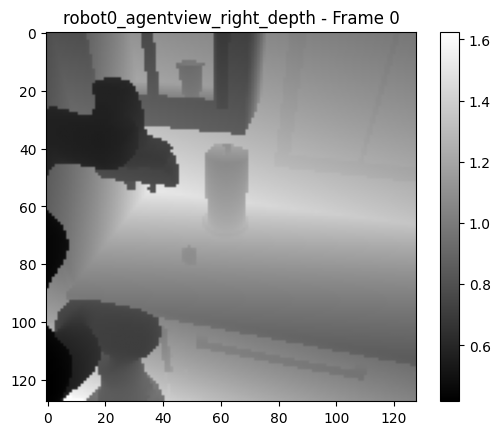

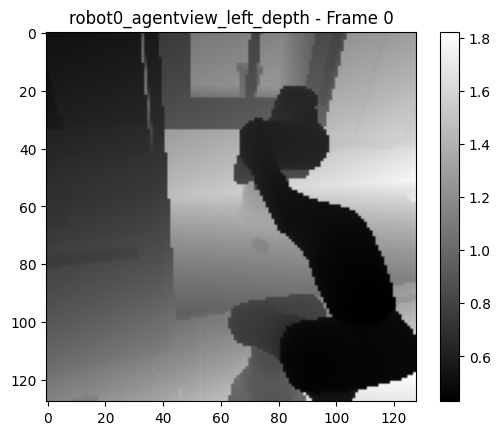

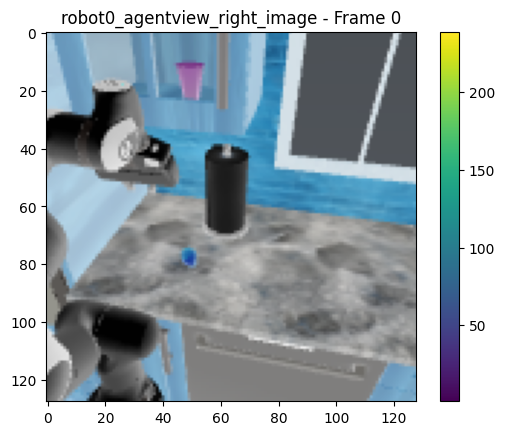

In [8]:
obs['robot0_agentview_right_depth']
import matplotlib.pyplot as plt
import numpy as np
# Get the depth data
depth_data = obs['robot0_agentview_right_depth'][:]

# Plot the first frame of the depth data
plt.imshow(depth_data[0, ::, :, 0], cmap='gray')
depth_data = np.clip(depth_data, 0, 10)
plt.title('robot0_agentview_right_depth - Frame 0')
plt.colorbar()
plt.show()

# Get the depth data
depth_data = obs['robot0_agentview_left_depth'][:]
depth_data = np.clip(depth_data, 0, 10)
# Plot the first frame of the depth data
plt.imshow(depth_data[0, ::, :, 0], cmap='gray')
plt.title('robot0_agentview_left_depth - Frame 0')
plt.colorbar()
plt.show()

rgb_data = obs['robot0_agentview_right_image'][:]

# Plot the first frame of the depth data
plt.imshow(rgb_data[0, ::, :])
plt.title('robot0_agentview_right_image - Frame 0')
plt.colorbar()
plt.show()

In [2]:
import os
os.environ["DISPLAY"] = ":0"
os.environ["QT_QPA_PLATFORM"]="offscreen"

In [1]:
!export QT_QPA_PLATFORM=offscreen

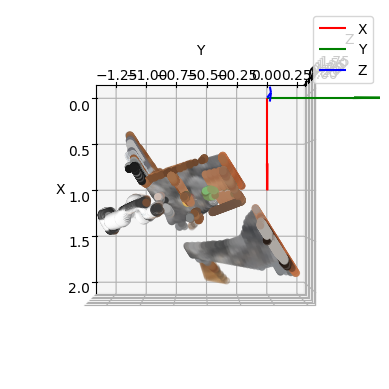

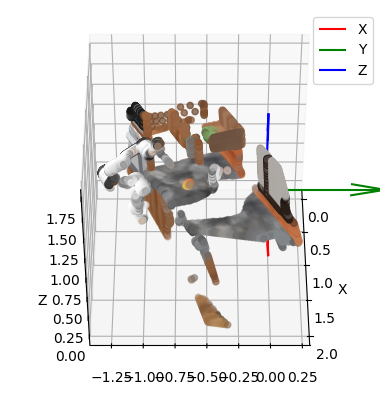

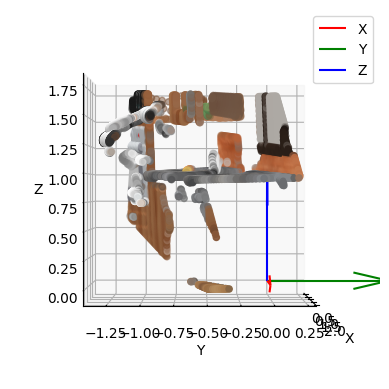

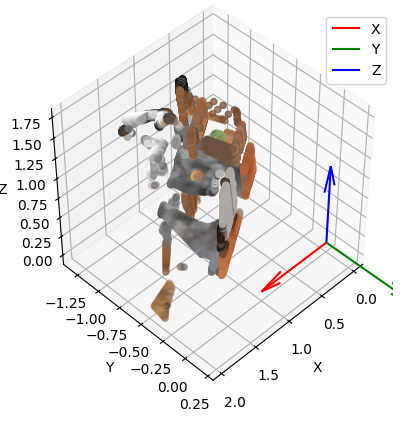

In [16]:

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib
import numpy as np
import open3d as o3d

import h5py
import json

# f = h5py.File("/home/arthur/Desktop/CMU/research/motorcortex/motor_cortex/benchmarks/robocasa/datasets/v0.1/single_stage/kitchen_doors/CloseSingleDoor/2024-04-24/demo_gentex_im128_randcams.hdf5")
# f = h5py.File("/home/arthur/Desktop/CMU/research/motorcortex/motor_cortex/benchmarks/robocasa/datasets/v0.1/single_stage/kitchen_doors/CloseSingleDoor/2024-04-24/demo_gentex_im128_randcams_im512.hdf5")
# f = h5py.File("/home/arthur/Desktop/CMU/research/motorcortex/motor_cortex/benchmarks/robocasa/datasets/v0.1/single_stage/kitchen_doors/CloseSingleDoor/2024-04-24/demo_gentex_im128_randcams_im360.hdf5")
# f = h5py.File("/home/arthur/Desktop/CMU/research/motorcortex/motor_cortex/benchmarks/robocasa/datasets/v0.1/single_stage/kitchen_doors/CloseSingleDoor/2024-04-24/demo_gentex_im128_randcams_im128.hdf5")
f = h5py.File("/home/arthur/Desktop/CMU/research/motorcortex/motor_cortex/benchmarks/robocasa/datasets/v0.1/single_stage/kitchen_doors/OpenSingleDoor/2024-04-24/demo_gentex_im128_randcams_im128.hdf5")

demo = f["data"]["demo_2"]                        # access demo 5
obs = demo["obs"]                                 # obervations across all timesteps


def rgbd_to_pointcloud(depth_map, rgb_image, intrinsic_matrix, extrinsic_matrix):
    # Get the height and width of the depth map
    height, width, _= depth_map.shape

    # # Create a mesh grid of pixel coordinates
    # u, v = np.meshgrid(np.arange(width), np.arange(height))

    # # Flatten arrays for processing
    # u = u.flatten()
    # v = v.flatten()
    # depth = depth_map.flatten()

    # # Intrinsic matrix inverse
    # fx, fy = intrinsic_matrix[0, 0], intrinsic_matrix[1, 1]
    # cx, cy = intrinsic_matrix[0, 2], intrinsic_matrix[1, 2]

    # # Unproject pixels to 3D in camera coordinates
    # x = (u - cx) * depth / fx
    # y = (v - cy) * depth / fy
    # z = depth

    # # Stack into Nx3 array of 3D points
    # points_camera = np.vstack((x, y, z)).T

    # # Transform points to world coordinates
    # # Add a column of ones for homogeneous coordinates
    # ones = np.ones((points_camera.shape[0], 1))
    # points_homogeneous = np.hstack((points_camera, ones))
    # points_world = (extrinsic_matrix @ points_homogeneous.T).T[:, :3]

    # # Get RGB values corresponding to each depth point
    # rgb_flat = rgb_image.reshape(-1, 3)  # Flatten the RGB image

    # # Filter points with valid depth
    # valid = depth > 0
    # points_world = points_world[valid]
    # colors = rgb_flat[valid]

    # # Create Open3D point cloud
    # point_cloud = o3d.geometry.PointCloud()
    # point_cloud.points = o3d.utility.Vector3dVector(points_world)
    # point_cloud.colors = o3d.utility.Vector3dVector(colors / 255.0)  # Normalize colors to [0, 1]

    # return point_cloud

     # Get image dimensions
    # height, width = depth_map.shape

    # Create a grid of (u, v) pixel coordinates
    u, v = np.meshgrid(np.arange(width), np.arange(height))

    # Flatten and stack pixel coordinates
    u_flat = u.flatten()
    v_flat = v.flatten()
    z_flat = depth_map.flatten()

    # Discard points with zero or invalid depth
    valid = z_flat > 0
    u_flat = u_flat[valid]
    v_flat = v_flat[valid]
    z_flat = z_flat[valid]

    # Intrinsic matrix inverse
    intrinsic_inv = np.linalg.inv(intrinsic_matrix)

    # Convert (u, v, 1) to camera coordinates
    pixel_coords = np.stack([u_flat, v_flat, np.ones_like(u_flat)], axis=1)
    camera_coords = (pixel_coords * z_flat[:, None]) @ intrinsic_inv.T

    # Add homogeneous coordinate for transformation
    camera_coords_hom = np.hstack([camera_coords, np.ones((camera_coords.shape[0], 1))])

    # Transform to world coordinates using the extrinsic matrix
    # world_coords_hom = (extrinsic_matrix @ camera_coords_hom.T).T
    # world_coords_hom = (np.linalg.inv(extrinsic_matrix) @ camera_coords_hom.T).T
    world_coords_hom = (camera_coords_hom @ extrinsic_matrix.T)



    # Extract 3D points
    pointcloud = world_coords_hom[:, :3]

    return pointcloud


intrinsic_matrix = np.array([[110.85125168,   0.          , 64. ],
                            [  0.         ,110.85125168  , 64. ],
                            [  0.         ,  0.           , 1. ],])
extrinsic_matrix = np.array([[ 0.9792974  , 0.09726106, -0.17752995,  1.2       ],
                            [ 0.20197353 ,-0.52812928,  0.82479461, -1.58      ],
                            [-0.01353837 ,-0.84357557, -0.5368398 ,  1.75      ],
                            [ 0.         , 0.        ,  0.        ,  1.        ],])


depth_map = obs['robot0_agentview_left_depth'][0]
rgb_image = obs['robot0_agentview_left_image'][0]

# Example Usage
# Assuming you have depth_map, rgb_image, intrinsic_matrix, and extrinsic_matrix
point_cloud = rgbd_to_pointcloud(depth_map, rgb_image, intrinsic_matrix, extrinsic_matrix)
def _visualize_pc(pc, rgb_image, elev=-45, azim=0):
    """
    Helper function to visualize the point cloud with colors.
    """
    colors=rgb_image.reshape(-1,3)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(pc[:, 0], pc[:, 1], pc[:, 2], c=colors[:,::-1])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    # plt.ion()
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_box_aspect([1, 1, 1])  # Set the aspect ratio to be equal

    # Initialize quivers for frame of reference
    quiver_x = ax.quiver(0, 0, 0, 1, 0, 0, color='r', label='X')
    quiver_y = ax.quiver(0, 0, 0, 0, 1, 0, color='g', label='Y')
    quiver_z = ax.quiver(0, 0, 0, 0, 0, 1, color='b', label='Z')
    ax.legend()

    # Set initial view
    ax.view_init(elev=elev, azim=azim)
    plt.show()


_visualize_pc(point_cloud, np.asarray(rgb_image.reshape(-1, 3)[:,::-1])/255.0, 90,0)
_visualize_pc(point_cloud, np.asarray(rgb_image.reshape(-1, 3)[:,::-1])/255.0, 45,0)
_visualize_pc(point_cloud, np.asarray(rgb_image.reshape(-1, 3)[:,::-1])/255.0, 0,0)
_visualize_pc(point_cloud, np.asarray(rgb_image.reshape(-1, 3)[:,::-1])/255.0, 45,45)


# Visualize the point cloud
# pc = np.asarray(point_cloud.points)
# _visualize_pc(pc, np.asarray(point_cloud.colors))

# Visualize point cloud
# import os
# os.environ['DISPLAY'] = ':0'
# o3d.visualization.draw_geometries([point_cloud])

# # Assuming `point_cloud` is your Open3D point cloud object
# vis = o3d.visualization.O3DVisualizer("Point Cloud", 1024, 768)
# vis.add_geometry(point_cloud)
# vis.show()

{'env_name': 'CloseSingleDoor',
 'env_version': '1.4.1',
 'type': 1,
 'env_kwargs': {'robots': 'PandaMobile',
  'controller_configs': {'type': 'OSC_POSE',
   'input_max': 1,
   'input_min': -1,
   'output_max': [0.05, 0.05, 0.05, 0.5, 0.5, 0.5],
   'output_min': [-0.05, -0.05, -0.05, -0.5, -0.5, -0.5],
   'kp': 150,
   'damping_ratio': 1,
   'impedance_mode': 'fixed',
   'kp_limits': [0, 300],
   'damping_ratio_limits': [0, 10],
   'position_limits': None,
   'orientation_limits': None,
   'uncouple_pos_ori': True,
   'control_delta': True,
   'interpolation': None,
   'ramp_ratio': 0.2},
  'layout_ids': -1,
  'style_ids': [0, 1, 2, 3, 4, 5, 6, 7, 8, 11],
  'translucent_robot': False,
  'obj_instance_split': 'A',
  'generative_textures': '100p',
  'randomize_cameras': True,
  'reward_shaping': False,
  'camera_names': ['robot0_agentview_left',
   'robot0_agentview_right',
   'robot0_eye_in_hand'],
  'camera_heights': 128,
  'camera_widths': 128,
  'has_renderer': False,
  'has_offscreen_renderer': True,
  'ignore_done': True,
  'use_object_obs': True,
  'use_camera_obs': True,
  'camera_depths': False}}

In [17]:
rgb_image.shape

(128, 128, 3)

In [28]:
import os
os.environ['DISPLAY']

':0'

In [4]:
env_meta = json.loads(f["data"].attrs["env_args"])
env_meta

{'env_name': 'CloseSingleDoor',
 'env_version': '1.5.0',
 'type': 1,
 'env_kwargs': {'robots': 'PandaMobile',
  'controller_configs': {'type': 'OSC_POSE',
   'input_max': 1,
   'input_min': -1,
   'output_max': [0.05, 0.05, 0.05, 0.5, 0.5, 0.5],
   'output_min': [-0.05, -0.05, -0.05, -0.5, -0.5, -0.5],
   'kp': 150,
   'damping_ratio': 1,
   'impedance_mode': 'fixed',
   'kp_limits': [0, 300],
   'damping_ratio_limits': [0, 10],
   'position_limits': None,
   'orientation_limits': None,
   'uncouple_pos_ori': True,
   'control_delta': True,
   'interpolation': None,
   'ramp_ratio': 0.2},
  'layout_ids': -1,
  'style_ids': [0, 1, 2, 3, 4, 5, 6, 7, 8, 11],
  'translucent_robot': False,
  'obj_instance_split': 'A',
  'generative_textures': '100p',
  'randomize_cameras': True,
  'camera_heights': 360,
  'camera_widths': 360,
  'has_renderer': False,
  'has_offscreen_renderer': True,
  'ignore_done': True,
  'use_object_obs': True,
  'use_camera_obs': True,
  'camera_depths': None,
  'rewa

In [ ]:
left_img = obs["robot0_agentview_left_image"][:]  # get left camera images in numpy format
ep_meta = json.loads(demo.attrs["ep_meta"])       # get meta data for episode
lang = ep_meta["lang"]                            # get language instruction for episode
f.close()

## Download dataset

First, let's try downloading a simple dataset - we'll use the Lift (PH) dataset. Note that there are utility scripts such as `scripts/download_datasets.py` to do this for us, but for the purposes of this example, we'll use the python API.

In [ ]:
import os
import json
import h5py
import numpy as np

import robomimic
import robomimic.utils.file_utils as FileUtils

# the dataset registry can be found at robomimic/__init__.py
from robomimic import DATASET_REGISTRY

# set download folder and make it
download_folder = "/tmp/robomimic_ds_example"
os.makedirs(download_folder, exist_ok=True)

# download the dataset
task = "lift"
dataset_type = "ph"
hdf5_type = "low_dim"
FileUtils.download_url(
    url=DATASET_REGISTRY[task][dataset_type][hdf5_type]["url"], 
    download_dir=download_folder,
)

# enforce that the dataset exists
dataset_path = os.path.join(download_folder, "low_dim_v141.hdf5")
assert os.path.exists(dataset_path)

## Read quantities from dataset

Next, let's demonstrate how to read different quantities from the dataset. There are scripts such as `scripts/get_dataset_info.py` that can help you easily understand the contents of a dataset, but in this example, we'll break down how to do this directly.

First, let's take a look at the number of demonstrations in the file.

In [ ]:
# open file
f = h5py.File(dataset_path, "r")

# each demonstration is a group under "data"
demos = list(f["data"].keys())
num_demos = len(demos)

print("hdf5 file {} has {} demonstrations".format(dataset_path, num_demos))

Next, let's list all of the demonstrations, along with the number of state-action pairs in each demonstration.

In [ ]:
# each demonstration is named "demo_#" where # is a number.
# Let's put the demonstration list in increasing episode order
inds = np.argsort([int(elem[5:]) for elem in demos])
demos = [demos[i] for i in inds]

for ep in demos:
    num_actions = f["data/{}/actions".format(ep)].shape[0]
    print("{} has {} samples".format(ep, num_actions))

Now, let's dig into a single trajectory to take a look at some of the quantities in each demonstration.

In [ ]:
# look at first demonstration
demo_key = demos[0]
demo_grp = f["data/{}".format(demo_key)]

# Each observation is a dictionary that maps modalities to numpy arrays, and
# each action is a numpy array. Let's print the observations and actions for the 
# first 5 timesteps of this trajectory.
for t in range(5):
    print("timestep {}".format(t))
    obs_t = dict()
    # each observation modality is stored as a subgroup
    for k in demo_grp["obs"]:
        obs_t[k] = demo_grp["obs/{}".format(k)][t] # numpy array
    act_t = demo_grp["actions"][t]
    
    # pretty-print observation and action using json
    obs_t_pp = { k : obs_t[k].tolist() for k in obs_t }
    print("obs")
    print(json.dumps(obs_t_pp, indent=4))
    print("action")
    print(act_t)

In [ ]:
# we can also grab multiple timesteps at once directly, or even the full trajectory at once
first_ten_actions = demo_grp["actions"][:10]
print("shape of first ten actions {}".format(first_ten_actions.shape))
all_actions = demo_grp["actions"][:]
print("shape of all actions {}".format(all_actions.shape))

In [ ]:
# the trajectory also contains the next observations under "next_obs", 
# for convenient use in a batch (offline) RL pipeline. Let's verify
# that "next_obs" and "obs" are offset by 1.
for k in demo_grp["obs"]:
    # obs_{t+1} == next_obs_{t}
    assert(np.allclose(demo_grp["obs"][k][1:], demo_grp["next_obs"][k][:-1]))
print("success")

In [ ]:
# we also have "done" and "reward" information stored in each trajectory.
# In this case, we have sparse rewards that indicate task completion at
# that timestep.
dones = demo_grp["dones"][:]
rewards = demo_grp["rewards"][:]
print("dones")
print(dones)
print("")
print("rewards")
print(rewards)

In [ ]:
# each demonstration also contains metadata
num_samples = demo_grp.attrs["num_samples"] # number of samples in this trajectory
mujoco_xml_file = demo_grp.attrs["model_file"] # mujoco XML file for this demonstration
print(mujoco_xml_file)

Finally, let's take a look at some global metadata present in the file. The hdf5 file stores environment metadata which is a convenient way to understand which simulation environment (task) the dataset was collected on. 

In [ ]:
env_meta = json.loads(f["data"].attrs["env_args"])
# note: we could also have used the following function:
# env_meta = FileUtils.get_env_metadata_from_dataset(dataset_path=dataset_path)
print("==== Env Meta ====")
print(json.dumps(env_meta, indent=4))
print("")

## Visualizing demonstration trajectories

Finally, let's play some of these demonstrations back in the simulation environment to easily visualize the data that was collected.

It turns out that the environment metadata stored in the hdf5 allows us to easily create a simulation environment that is consistent with the way the dataset was collected!

In [ ]:
import robomimic.utils.env_utils as EnvUtils

# create simulation environment from environment metedata
env = EnvUtils.create_env_from_metadata(
    env_meta=env_meta, 
    render=False,            # no on-screen rendering
    render_offscreen=True,   # off-screen rendering to support rendering video frames
)

In [ ]:
import robomimic.utils.obs_utils as ObsUtils

# We normally need to make sure robomimic knows which observations are images (for the
# data processing pipeline). This is usually inferred from your training config, but
# since we are just playing back demonstrations, we just need to initialize robomimic
# with a dummy spec.
dummy_spec = dict(
    obs=dict(
            low_dim=["robot0_eef_pos"],
            rgb=[],
        ),
)
ObsUtils.initialize_obs_utils_with_obs_specs(obs_modality_specs=dummy_spec)

In [ ]:
import imageio

# prepare to write playback trajectories to video
video_path = os.path.join(download_folder, "playback.mp4")
video_writer = imageio.get_writer(video_path, fps=20)

In [ ]:
def playback_trajectory(demo_key):
    """
    Simple helper function to playback the trajectory stored under the hdf5 group @demo_key and
    write frames rendered from the simulation to the active @video_writer.
    """
    
    # robosuite datasets store the ground-truth simulator states under the "states" key.
    # We will use the first one, alone with the model xml, to reset the environment to
    # the initial configuration before playing back actions.
    init_state = f["data/{}/states".format(demo_key)][0]
    model_xml = f["data/{}".format(demo_key)].attrs["model_file"]
    initial_state_dict = dict(states=init_state, model=model_xml)
    
    # reset to initial state
    env.reset_to(initial_state_dict)
    
    # playback actions one by one, and render frames
    actions = f["data/{}/actions".format(demo_key)][:]
    for t in range(actions.shape[0]):
        env.step(actions[t])
        video_img = env.render(mode="rgb_array", height=512, width=512, camera_name="agentview")
        video_writer.append_data(video_img)

In [ ]:
# playback the first 5 demos
for ep in demos[:5]:
    print("Playing back demo key: {}".format(ep))
    playback_trajectory(ep)

# done writing video
video_writer.close()

In [ ]:
# view the trajectories!
from IPython.display import Video
Video(video_path, embed=True)